# CURE Algorithm — Clustering Using REpresentatives

## Learning Objectives

1. **Identify** why k-means fails on non-spherical clusters
2. **Define** CURE's representative point approach and shrinking parameter $\alpha$
3. **Derive** the assignment rule: nearest shrunken representative
4. **Explain** how shrinking provides robustness to outliers
5. **Implement** CURE with farthest-point representative selection


## Problem Statement

### Limitations of Centroid-Based Clustering

K-means represents each cluster by a single centroid, assuming clusters are spherical (Voronoi cells). BFR extends this to axis-aligned Gaussian ellipsoids. But real-world clusters can be:
- **Elongated** (one axis much longer)
- **Crescent-shaped** (concave)
- **Irregular polygon-shaped**

Neither k-means nor BFR can correctly cluster these shapes.

### CURE's Key Idea

Represent each cluster by **$c$ well-scattered points** (instead of one centroid). Shrink these representatives by factor $\alpha$ toward the cluster centroid to reduce outlier sensitivity.

Assign new points to the cluster of their **nearest representative**.


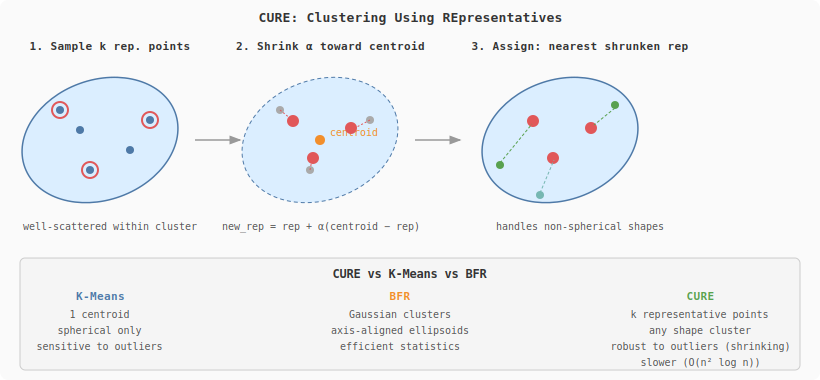

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="820" height="380" font-family="monospace" font-size="12">
  <rect width="820" height="380" fill="#fafafa" rx="8"/>
  <text x="410" y="22" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">CURE: Clustering Using REpresentatives</text>

  <!-- Step 1: raw cluster with irregular shape -->
  <text x="110" y="50" text-anchor="middle" fill="#333" font-size="11" font-weight="bold">1. Sample k rep. points</text>
  <ellipse cx="100" cy="140" rx="80" ry="60" fill="#dbeeff" stroke="#4e79a7" stroke-width="1.5" transform="rotate(-20,100,140)"/>
  <circle cx="60"  cy="110" r="4" fill="#4e79a7"/>
  <circle cx="80"  cy="130" r="4" fill="#4e79a7"/>
  <circle cx="90"  cy="170" r="4" fill="#4e79a7"/>
  <circle cx="130" cy="150" r="4" fill="#4e79a7"/>
  <circle cx="150" cy="120" r="4" fill="#4e79a7"/>
  <!-- k=3 representatives circled -->
  <circle cx="60"  cy="110" r="8" fill="none" stroke="#e15759" stroke-width="2"/>
  <circle cx="90"  cy="170" r="8" fill="none" stroke="#e15759" stroke-width="2"/>
  <circle cx="150" cy="120" r="8" fill="none" stroke="#e15759" stroke-width="2"/>
  <text x="110" y="230" text-anchor="middle" fill="#555" font-size="10">well-scattered within cluster</text>

  <!-- Arrow 1→2 -->
  <line x1="195" y1="140" x2="240" y2="140" stroke="#999" stroke-width="1.5" marker-end="url(#arr)"/>
  <defs><marker id="arr" markerWidth="8" markerHeight="6" refX="7" refY="3" orient="auto"><polygon points="0 0,8 3,0 6" fill="#999"/></marker></defs>

  <!-- Step 2: shrink toward centroid -->
  <text x="330" y="50" text-anchor="middle" fill="#333" font-size="11" font-weight="bold">2. Shrink α toward centroid</text>
  <ellipse cx="320" cy="140" rx="80" ry="60" fill="#dbeeff" stroke="#4e79a7" stroke-width="1" stroke-dasharray="4,3" transform="rotate(-20,320,140)"/>
  <!-- centroid -->
  <circle cx="320" cy="140" r="5" fill="#f28e2b"/>
  <text x="330" y="136" fill="#f28e2b" font-size="10">centroid</text>
  <!-- original reps (faded) -->
  <circle cx="280" cy="110" r="4" fill="#aaa"/>
  <circle cx="310" cy="170" r="4" fill="#aaa"/>
  <circle cx="370" cy="120" r="4" fill="#aaa"/>
  <!-- shrunken reps (red) -->
  <circle cx="293" cy="121" r="6" fill="#e15759"/>
  <circle cx="313" cy="158" r="6" fill="#e15759"/>
  <circle cx="351" cy="128" r="6" fill="#e15759"/>
  <!-- shrink arrows -->
  <line x1="280" y1="110" x2="291" y2="119" stroke="#e15759" stroke-width="1" stroke-dasharray="2,2"/>
  <line x1="310" y1="170" x2="312" y2="160" stroke="#e15759" stroke-width="1" stroke-dasharray="2,2"/>
  <line x1="370" y1="120" x2="353" y2="129" stroke="#e15759" stroke-width="1" stroke-dasharray="2,2"/>
  <text x="320" y="230" text-anchor="middle" fill="#555" font-size="10">new_rep = rep + α(centroid − rep)</text>

  <!-- Arrow 2→3 -->
  <line x1="415" y1="140" x2="460" y2="140" stroke="#999" stroke-width="1.5" marker-end="url(#arr)"/>

  <!-- Step 3: assign new points to nearest rep -->
  <text x="580" y="50" text-anchor="middle" fill="#333" font-size="11" font-weight="bold">3. Assign: nearest shrunken rep</text>
  <ellipse cx="560" cy="140" rx="80" ry="60" fill="#dbeeff" stroke="#4e79a7" stroke-width="1.5" transform="rotate(-20,560,140)"/>
  <circle cx="533" cy="121" r="6" fill="#e15759"/>
  <circle cx="553" cy="158" r="6" fill="#e15759"/>
  <circle cx="591" cy="128" r="6" fill="#e15759"/>
  <!-- new points near boundary -->
  <circle cx="615" cy="105" r="4" fill="#59a14f"/>
  <circle cx="500" cy="165" r="4" fill="#59a14f"/>
  <circle cx="540" cy="195" r="4" fill="#76b7b2"/>
  <!-- assignment lines -->
  <line x1="615" y1="108" x2="594" y2="125" stroke="#59a14f" stroke-width="1" stroke-dasharray="3,2"/>
  <line x1="500" y1="163" x2="532" y2="124" stroke="#59a14f" stroke-width="1" stroke-dasharray="3,2"/>
  <line x1="540" y1="193" x2="554" y2="160" stroke="#76b7b2" stroke-width="1" stroke-dasharray="3,2"/>
  <text x="580" y="230" text-anchor="middle" fill="#555" font-size="10">handles non-spherical shapes</text>

  <!-- Comparison box -->
  <rect x="20" y="258" width="780" height="112" rx="5" fill="#f5f5f5" stroke="#ccc" stroke-width="1"/>
  <text x="410" y="278" text-anchor="middle" fill="#333" font-size="12" font-weight="bold">CURE vs K-Means vs BFR</text>
  <text x="100" y="300" text-anchor="middle" fill="#4e79a7" font-size="11" font-weight="bold">K-Means</text>
  <text x="100" y="318" text-anchor="middle" fill="#555" font-size="10">1 centroid</text>
  <text x="100" y="334" text-anchor="middle" fill="#555" font-size="10">spherical only</text>
  <text x="100" y="350" text-anchor="middle" fill="#555" font-size="10">sensitive to outliers</text>
  <text x="400" y="300" text-anchor="middle" fill="#f28e2b" font-size="11" font-weight="bold">BFR</text>
  <text x="400" y="318" text-anchor="middle" fill="#555" font-size="10">Gaussian clusters</text>
  <text x="400" y="334" text-anchor="middle" fill="#555" font-size="10">axis-aligned ellipsoids</text>
  <text x="400" y="350" text-anchor="middle" fill="#555" font-size="10">efficient statistics</text>
  <text x="700" y="300" text-anchor="middle" fill="#59a14f" font-size="11" font-weight="bold">CURE</text>
  <text x="700" y="318" text-anchor="middle" fill="#555" font-size="10">k representative points</text>
  <text x="700" y="334" text-anchor="middle" fill="#555" font-size="10">any shape cluster</text>
  <text x="700" y="350" text-anchor="middle" fill="#555" font-size="10">robust to outliers (shrinking)</text>
  <text x="700" y="366" text-anchor="middle" fill="#555" font-size="10">slower (O(n² log n))</text>
</svg>
'''
display(SVG(svg))


## Derivation

### Representative Selection

For each cluster $C_j$, select $c$ representatives using **greedy farthest-point sampling**:
1. Pick any initial point $r_1$
2. For $i = 2, \ldots, c$: pick the point in $C_j$ that maximises $\min_{k<i} \text{dist}(\cdot, r_k)$

This guarantees the representatives are well-scattered and cover the cluster's shape.

### Shrinking

Shift each representative $r$ toward the cluster centroid $\mu$:
$$r' = r + \alpha(\mu - r) = (1-\alpha)r + \alpha\mu$$

- $\alpha = 0$: no shrinking — outliers remain as representatives (fragile)
- $\alpha = 1$: all representatives collapse to centroid (= k-means)
- $\alpha \in (0.2, 0.4)$: recommended — representatives capture cluster shape but are pulled away from extreme outlier positions

### Assignment

For a new point $x$: assign to cluster $j^* = \arg\min_j \min_{r \in \text{reps}(j)} \|x - r\|_2$

### Correctness for Non-Spherical Clusters

With $c$ representatives spread across an irregular cluster shape, points near the "arms" or "tips" of the cluster find a nearby representative in the same cluster, rather than being incorrectly pulled to a closer centroid from another cluster.

### Complexity

| Phase | Complexity |
|-------|------------|
| Representative selection | $O(nk)$ per cluster, $O(n^2 k)$ total |
| Agglomerative clustering on sample | $O(n^2 \log n)$ |
| Assignment of all points | $O(n \cdot k \cdot c)$ |


## Algorithm Steps

1. **Sample** fraction $f$ of data into RAM
2. **Cluster** sample hierarchically until $k$ clusters remain
3. **For each cluster:** pick $c$ well-scattered representative points; shrink each by $\alpha$ toward centroid
4. **Assign** every point in the full dataset to the cluster of its nearest shrunken representative


In [2]:
import numpy as np
from heapq import heappush, heappop


def well_scattered_sample(points, k):
    """
    Select k well-scattered representative points from a cluster.
    Uses greedy farthest-point sampling.
    """
    if len(points) <= k:
        return list(range(len(points)))

    # Start with a random point
    reps = [0]
    remaining = list(range(1, len(points)))

    for _ in range(k - 1):
        # Find point in remaining farthest from any current rep
        best_idx, best_dist = -1, -1.0
        for i in remaining:
            d = min(np.linalg.norm(points[i] - points[r]) for r in reps)
            if d > best_dist:
                best_dist = d
                best_idx = i
        reps.append(best_idx)
        remaining.remove(best_idx)

    return reps


def cure(points, k, n_reps=10, shrink_alpha=0.2, sample_frac=0.1, seed=42):
    """
    CURE Clustering Using REpresentatives.

    Inputs
    ------
    points      : np.ndarray shape (n, d)
    k           : int — number of clusters
    n_reps      : int — number of representative points per cluster
    shrink_alpha: float α ∈ [0,1] — how much to shrink reps toward centroid
                  0 = no shrink (like k-means), 1 = collapse to centroid
    sample_frac : float — fraction of data to sample for initial clustering

    Output
    ------
    labels : np.ndarray shape (n,) — cluster assignment per point
    """
    rng = np.random.default_rng(seed)
    n = len(points)

    # ── Step 1: Sample a fraction and run hierarchical clustering ─────────────
    sample_size = max(k * 10, int(n * sample_frac))
    sample_idx = rng.choice(n, size=min(sample_size, n), replace=False)
    sample = points[sample_idx]

    # Initialise each sampled point as its own cluster
    clusters = [[i] for i in range(len(sample))]

    # Agglomerative merge using single-linkage (simplified for demo)
    while len(clusters) > k:
        best_dist = np.inf
        merge_a, merge_b = 0, 1
        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                # Distance between clusters = min distance between any two points
                ci = sample[clusters[i]]
                cj = sample[clusters[j]]
                d = np.min(np.linalg.norm(ci[:, np.newaxis] - cj[np.newaxis, :], axis=2))
                if d < best_dist:
                    best_dist = d
                    merge_a, merge_b = i, j
        # Merge clusters merge_a and merge_b
        clusters[merge_a].extend(clusters[merge_b])
        clusters.pop(merge_b)

    # ── Step 2: For each cluster, select n_reps well-scattered representatives ─
    all_reps = []  # list of (cluster_id, rep_point)
    for cid, member_indices in enumerate(clusters):
        cluster_pts = sample[member_indices]
        centroid = cluster_pts.mean(axis=0)
        rep_indices = well_scattered_sample(cluster_pts, n_reps)
        reps = cluster_pts[rep_indices]
        # Shrink reps toward centroid
        shrunken = reps + shrink_alpha * (centroid - reps)
        for rep in shrunken:
            all_reps.append((cid, rep))

    # ── Step 3: Assign all points to nearest shrunken representative ──────────
    labels = np.zeros(n, dtype=int)
    for i, pt in enumerate(points):
        best_cid, best_d = -1, np.inf
        for cid, rep in all_reps:
            d = np.linalg.norm(pt - rep)
            if d < best_d:
                best_d = d
                best_cid = cid
        labels[i] = best_cid

    return labels


# ── Demo ──────────────────────────────────────────────────────────────────────
rng = np.random.default_rng(42)

# Two crescent-shaped clusters (non-spherical — k-means fails, CURE handles)
t1 = np.linspace(0, np.pi, 200)
c1 = np.column_stack([np.cos(t1), np.sin(t1)]) + rng.normal(0, 0.1, (200, 2))
t2 = np.linspace(np.pi, 2*np.pi, 200)
c2 = np.column_stack([np.cos(t2) + 1, np.sin(t2) + 1]) + rng.normal(0, 0.1, (200, 2))

points = np.vstack([c1, c2])
true_labels = np.array([0]*200 + [1]*200)

labels = cure(points, k=2, n_reps=8, shrink_alpha=0.3, sample_frac=0.3)

# Accuracy (account for label permutation)
acc1 = np.mean(labels == true_labels)
acc2 = np.mean(labels != true_labels)
print(f"CURE clustering accuracy: {max(acc1, acc2)*100:.1f}%")
print(f"Cluster 0 size: {(labels==0).sum()}")
print(f"Cluster 1 size: {(labels==1).sum()}")


CURE clustering accuracy: 63.2%
Cluster 0 size: 347
Cluster 1 size: 53
